### <h1 style="color: blue;">Import Necessary Libraries</h1>

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from ctgan import CTGAN
#!pip install ydata-profiling
from ydata_profiling import ProfileReport
#!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

### <h1 style="color: blue;">Load Data</h1>

In [3]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.shape

(2111, 17)

### <h1 style="color: blue;">Data Cleaning</h1>

In [6]:
#First we will convert all the column names to lowercase and change few of the names to make those easily conprehensive.
#This is going to be based on the description provided by the data compilers.
df.columns = df.columns.str.lower()
df.rename(columns= {'height' : 'height_in_meters', 'weight' : 'weight_in_kgs',
                               'favc' : 'high_calorie_food_intake', 'fcvc' : 'vegetables_in_meal', 
                               'ncp' : 'number_of_daily_meals', 'caec' : 'food_between_meals', 'smoke' : 'smoking_status', 
                               'ch2o' : 'amount_of_water_daily_in_liters', 'scc' : 'calorie_monitoring', 'faf': 'frequency_physical_activity_days_per_week', 
                               'tue' : 'use_of_tech_device_time_in_hours', 'calc' : 'frequency_alcohol_drinking',
                              'mtrans' : 'type_of_transport', 'nobeyesdad' : 'obesity_level'}, inplace=True)
df.head(3)

,gender,age,height_in_meters,weight_in_kgs,family_history_with_overweight,high_calorie_food_intake,vegetables_in_meal,number_of_daily_meals,food_between_meals,smoking_status,amount_of_water_daily_in_liters,calorie_monitoring,frequency_physical_activity_days_per_week,use_of_tech_device_time_in_hours,frequency_alcohol_drinking,type_of_transport,obesity_level
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight


In [7]:
# Check for NA values
df.isna().sum()

gender                                       0
age                                          0
height_in_meters                             0
weight_in_kgs                                0
family_history_with_overweight               0
high_calorie_food_intake                     0
vegetables_in_meal                           0
number_of_daily_meals                        0
food_between_meals                           0
smoking_status                               0
amount_of_water_daily_in_liters              0
calorie_monitoring                           0
frequency_physical_activity_days_per_week    0
use_of_tech_device_time_in_hours             0
frequency_alcohol_drinking                   0
type_of_transport                            0
obesity_level                                0
dtype: int64

In [8]:
#We can see that there are no NA values
#Now we need to check if there are duplicate values
df.duplicated().sum()

24

In [9]:
all_duplicate_rows = df[df.duplicated(keep=False)]
#print(all_duplicate_rows)

In [10]:
#We can see that there are some duplicate rows in the dataset. We need to remove duplicates, by keeping first occerence
#between the duplicates as follows
df1 = df.drop_duplicates()

In [11]:
df1.duplicated().sum()

0

In [12]:
df1.shape

(2087, 17)

In [13]:
#Above, we can see that the duplicate rows are removed.

In [14]:
df1.describe()

,age,height_in_meters,weight_in_kgs,vegetables_in_meal,number_of_daily_meals,amount_of_water_daily_in_liters,frequency_physical_activity_days_per_week,use_of_tech_device_time_in_hours
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [15]:
#Above is the description of numerical columns. Let us see how each variable looks like.
# 'age', 'height_in_meters', 'weight_in_kgs', 'amount_of_water_daily_in_liters' columns look fine.
# 'vegetables_in_meal' column is supposed to be categorical but looks continuous. It is unclear why it is so, but we will
#keep it as it is for now. 'number_of_daily_meals' needs to be integer but is continuous. We will keep it that way because changing it might
#result in loss of information.
#'frequency_physical_activity_days_per_week' column needs to be have discrete values. Same thing is true for 'use_of_tech_device_time_in_hours' column.
#But we will keep those as they are.

### <h1 style="color: blue;">Check The Numeric Columns</h1>

In [17]:
#Get all the numeric columns
numeric_columns = df1.select_dtypes(include=['float64', 'int64']).columns
numeric_columns

Index(['age', 'height_in_meters', 'weight_in_kgs', 'vegetables_in_meal',
       'number_of_daily_meals', 'amount_of_water_daily_in_liters',
       'frequency_physical_activity_days_per_week',
       'use_of_tech_device_time_in_hours'],
      dtype='object')

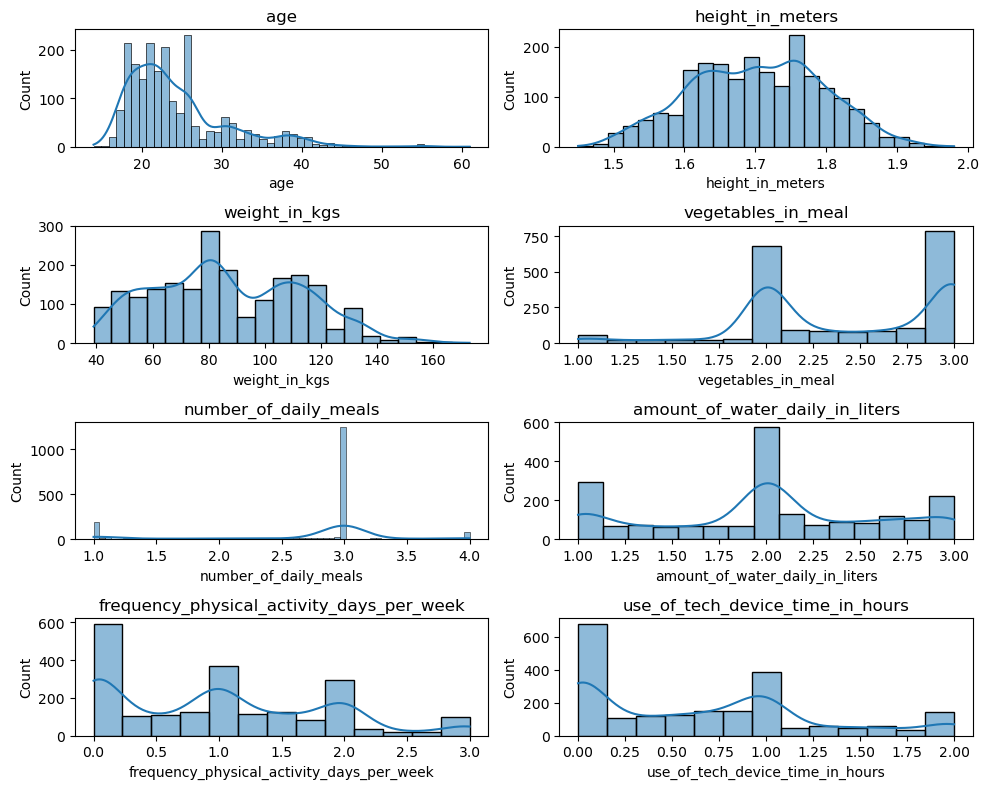

In [18]:
#Plot the distribution of the numeric columns to check those visually

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.histplot(df1[column], kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [19]:
#All the plots look good. Following are the observations of the plots.

#### 1. Most of the people are between the age group 15 - 35
#### 2. The weight ranges from 39 kg to more than 173 kg, it is possible that many people are overweight based on the BMI.
#### 3. Many people consume good amount of vegetables in meals.
#### 4. Most of the people eat 3 meals per day while some eat 1 or 4.
#### 5. Amount of water consumption varies from 1 to 3 liters per day. 
#### 5. Many people do not do daily physical workouts. Very less people workout for 3 days per week.
#### 6. Time of using technical devices varies from 0 hour to 2 hours.

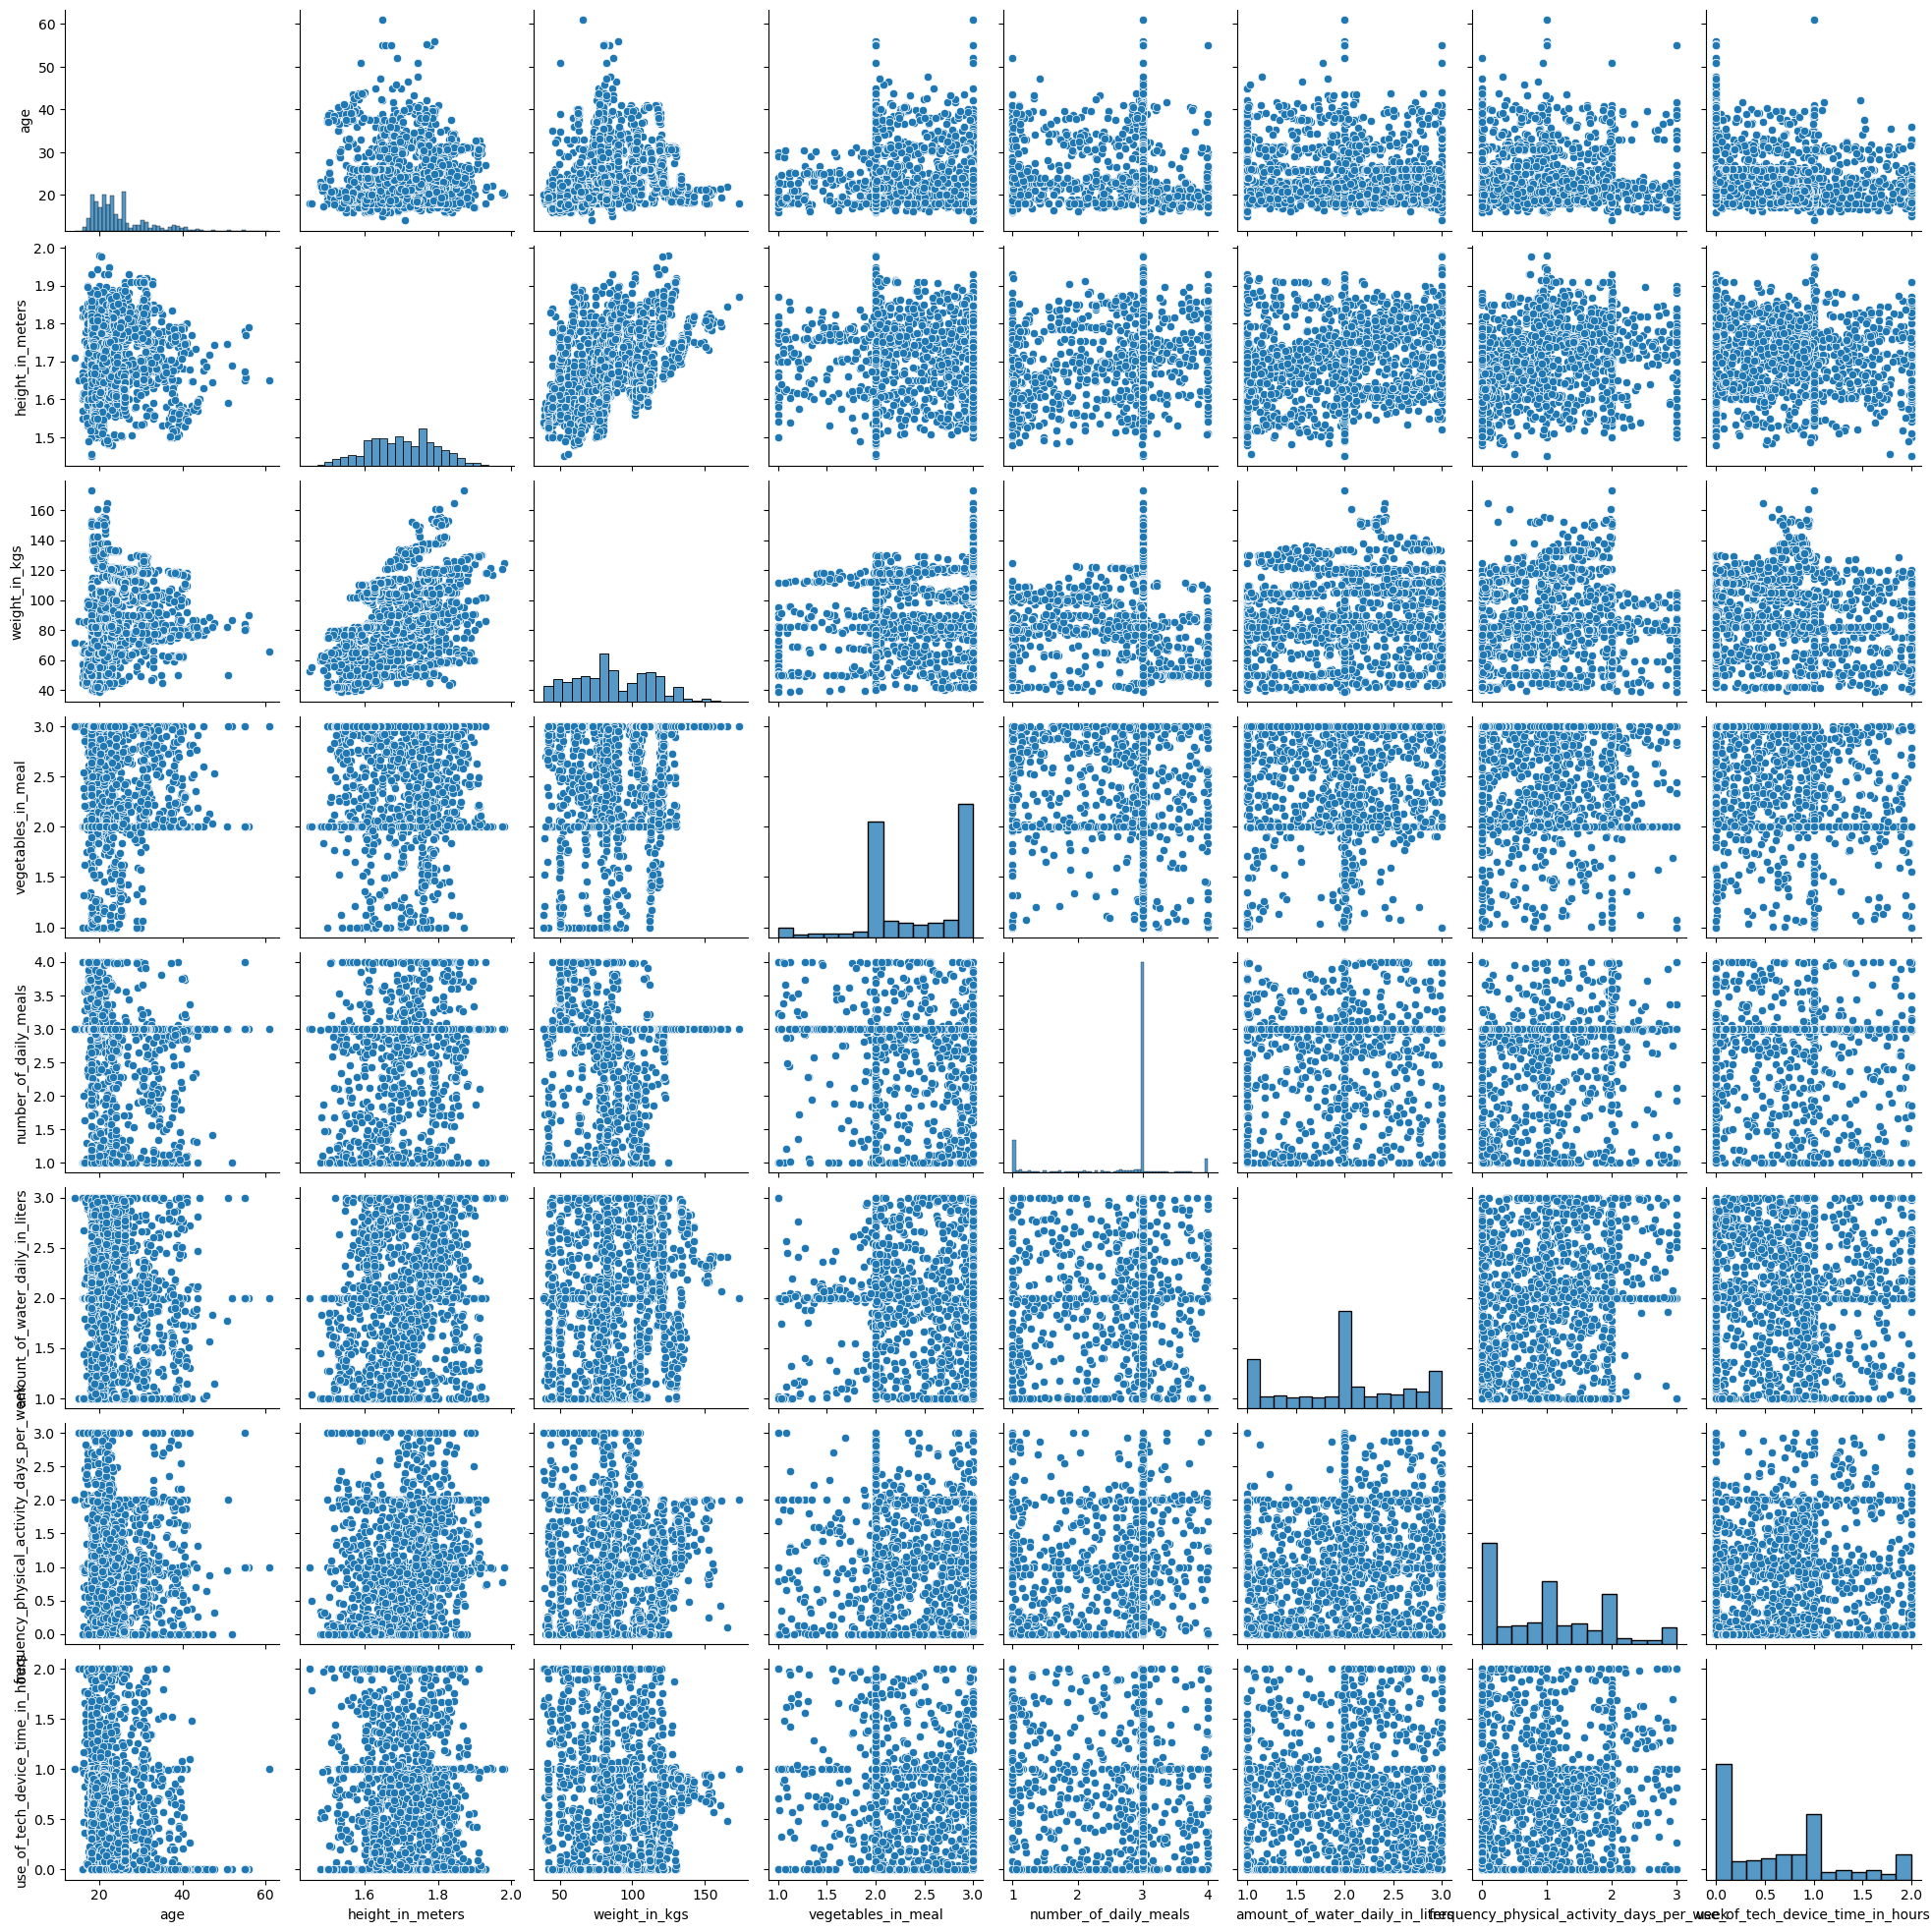

In [21]:
#Show pairwise plots to observe how every variable is related to every other variable
sns.pairplot(df1)
plt.show()

In [22]:
#In above plots we can see height and weight are highly correlated. No other variables show strong correlation. 

### <h1 style="color: blue;">Outlier Treatment</h1>

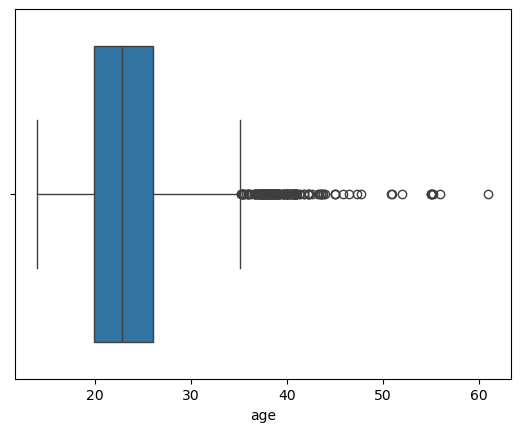

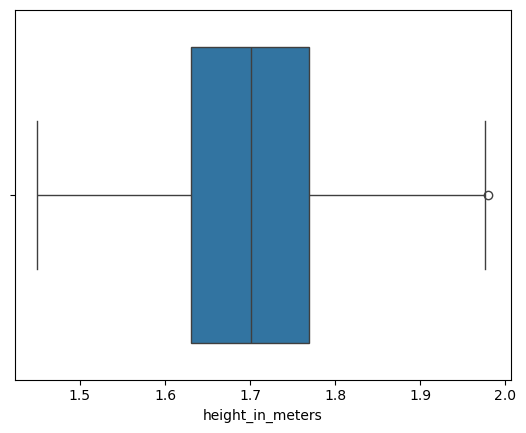

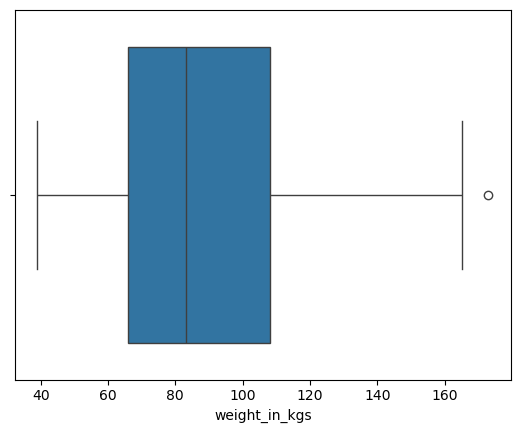

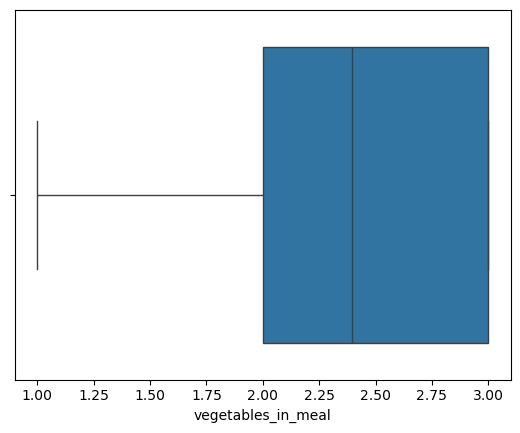

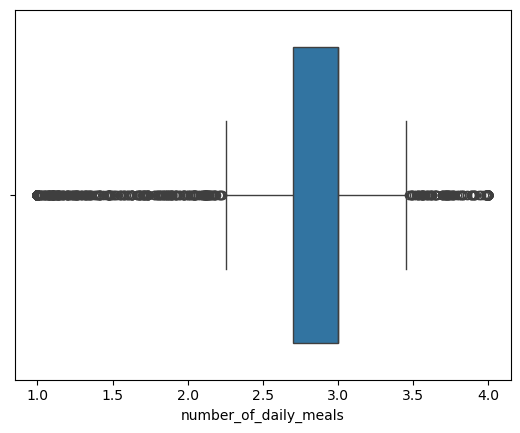

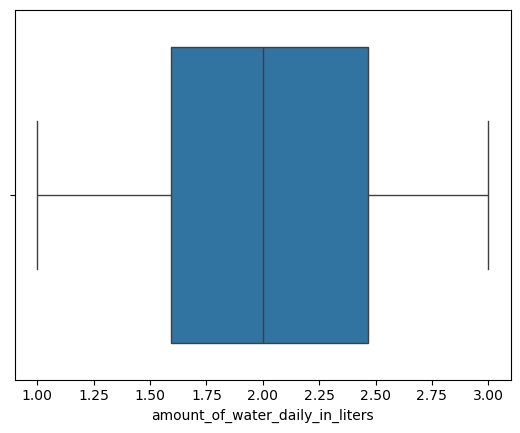

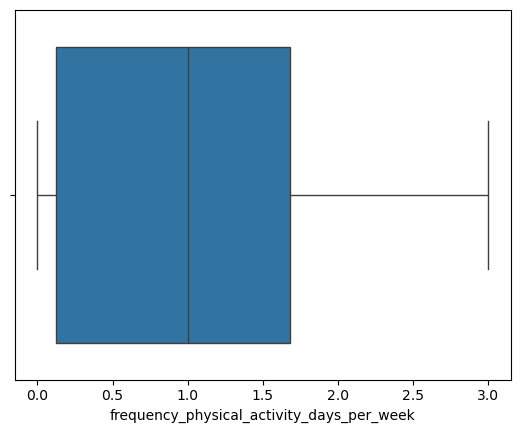

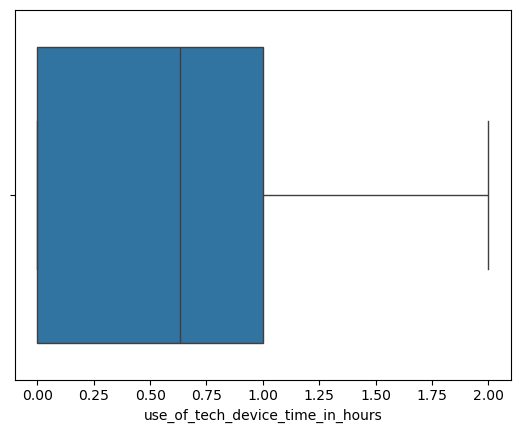

In [24]:
for col in numeric_columns:
    sns.boxplot(x=df1[col])
    plt.show()

In [25]:
for cols in df1.columns:            
    if df1[cols].dtype == object :       # Selecting only numerical column
        continue
    else:
        Q1 = df1[cols].quantile(q=0.25)
        Q3 = df1[cols].quantile(q=0.75)
        iqr = Q3-Q1
        
        low = Q1 - 1.5*(Q3-Q1)          
        high = Q3 + 1.5*(Q3-Q1)
        df1.loc[(df1[cols]<low) | (df1[cols]>high),cols] = df1[cols].median()   # Replacing outliers with median
       # df1.loc[(df1[cols]<low) | (df1[cols]>high),cols] = df1[cols].quantile(0.99)   # Replacing outliers with 99th percentile value

In [26]:
df1.describe()

,age,height_in_meters,weight_in_kgs,vegetables_in_meal,number_of_daily_meals,amount_of_water_daily_in_liters,frequency_physical_activity_days_per_week,use_of_tech_device_time_in_hours
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,22.967401,1.702541,86.815654,2.421466,2.976794,2.004749,1.012812,0.663035
std,4.152803,0.092988,26.122944,0.534737,0.126218,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,2.256119,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,3.000000,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,25.540138,1.769406,108.006302,3.000000,3.000000,2.466193,1.678102,1.000000
max,35.125401,1.975663,165.057269,3.000000,3.452590,3.000000,3.000000,2.000000


#### This way we have treated the outliers

### <h1 style="color: blue;">Check The Categorical Columns</h1>

In [29]:
#We will check the unique values in categorical columns
categorical_cols = ['gender', 'family_history_with_overweight', 'high_calorie_food_intake', 'food_between_meals', 
                   'smoking_status', 'calorie_monitoring', 'frequency_alcohol_drinking', 'type_of_transport', 'obesity_level']
for col in categorical_cols:
    print(col, ":", df1[col].unique())

gender : ['Female' 'Male']
family_history_with_overweight : ['yes' 'no']
high_calorie_food_intake : ['no' 'yes']
food_between_meals : ['Sometimes' 'Frequently' 'Always' 'no']
smoking_status : ['no' 'yes']
calorie_monitoring : ['no' 'yes']
frequency_alcohol_drinking : ['no' 'Sometimes' 'Frequently' 'Always']
type_of_transport : ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
obesity_level : ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


#### Above we can see the unique values in each categorical column.

In [31]:
#We will check the percentage count for age column
pct_count = df1['gender'].value_counts(normalize=True)*100
pct_count

gender
Male      50.407283
Female    49.592717
Name: proportion, dtype: float64

In [32]:
#Roughly equal amount of male and female gender distribution is there.

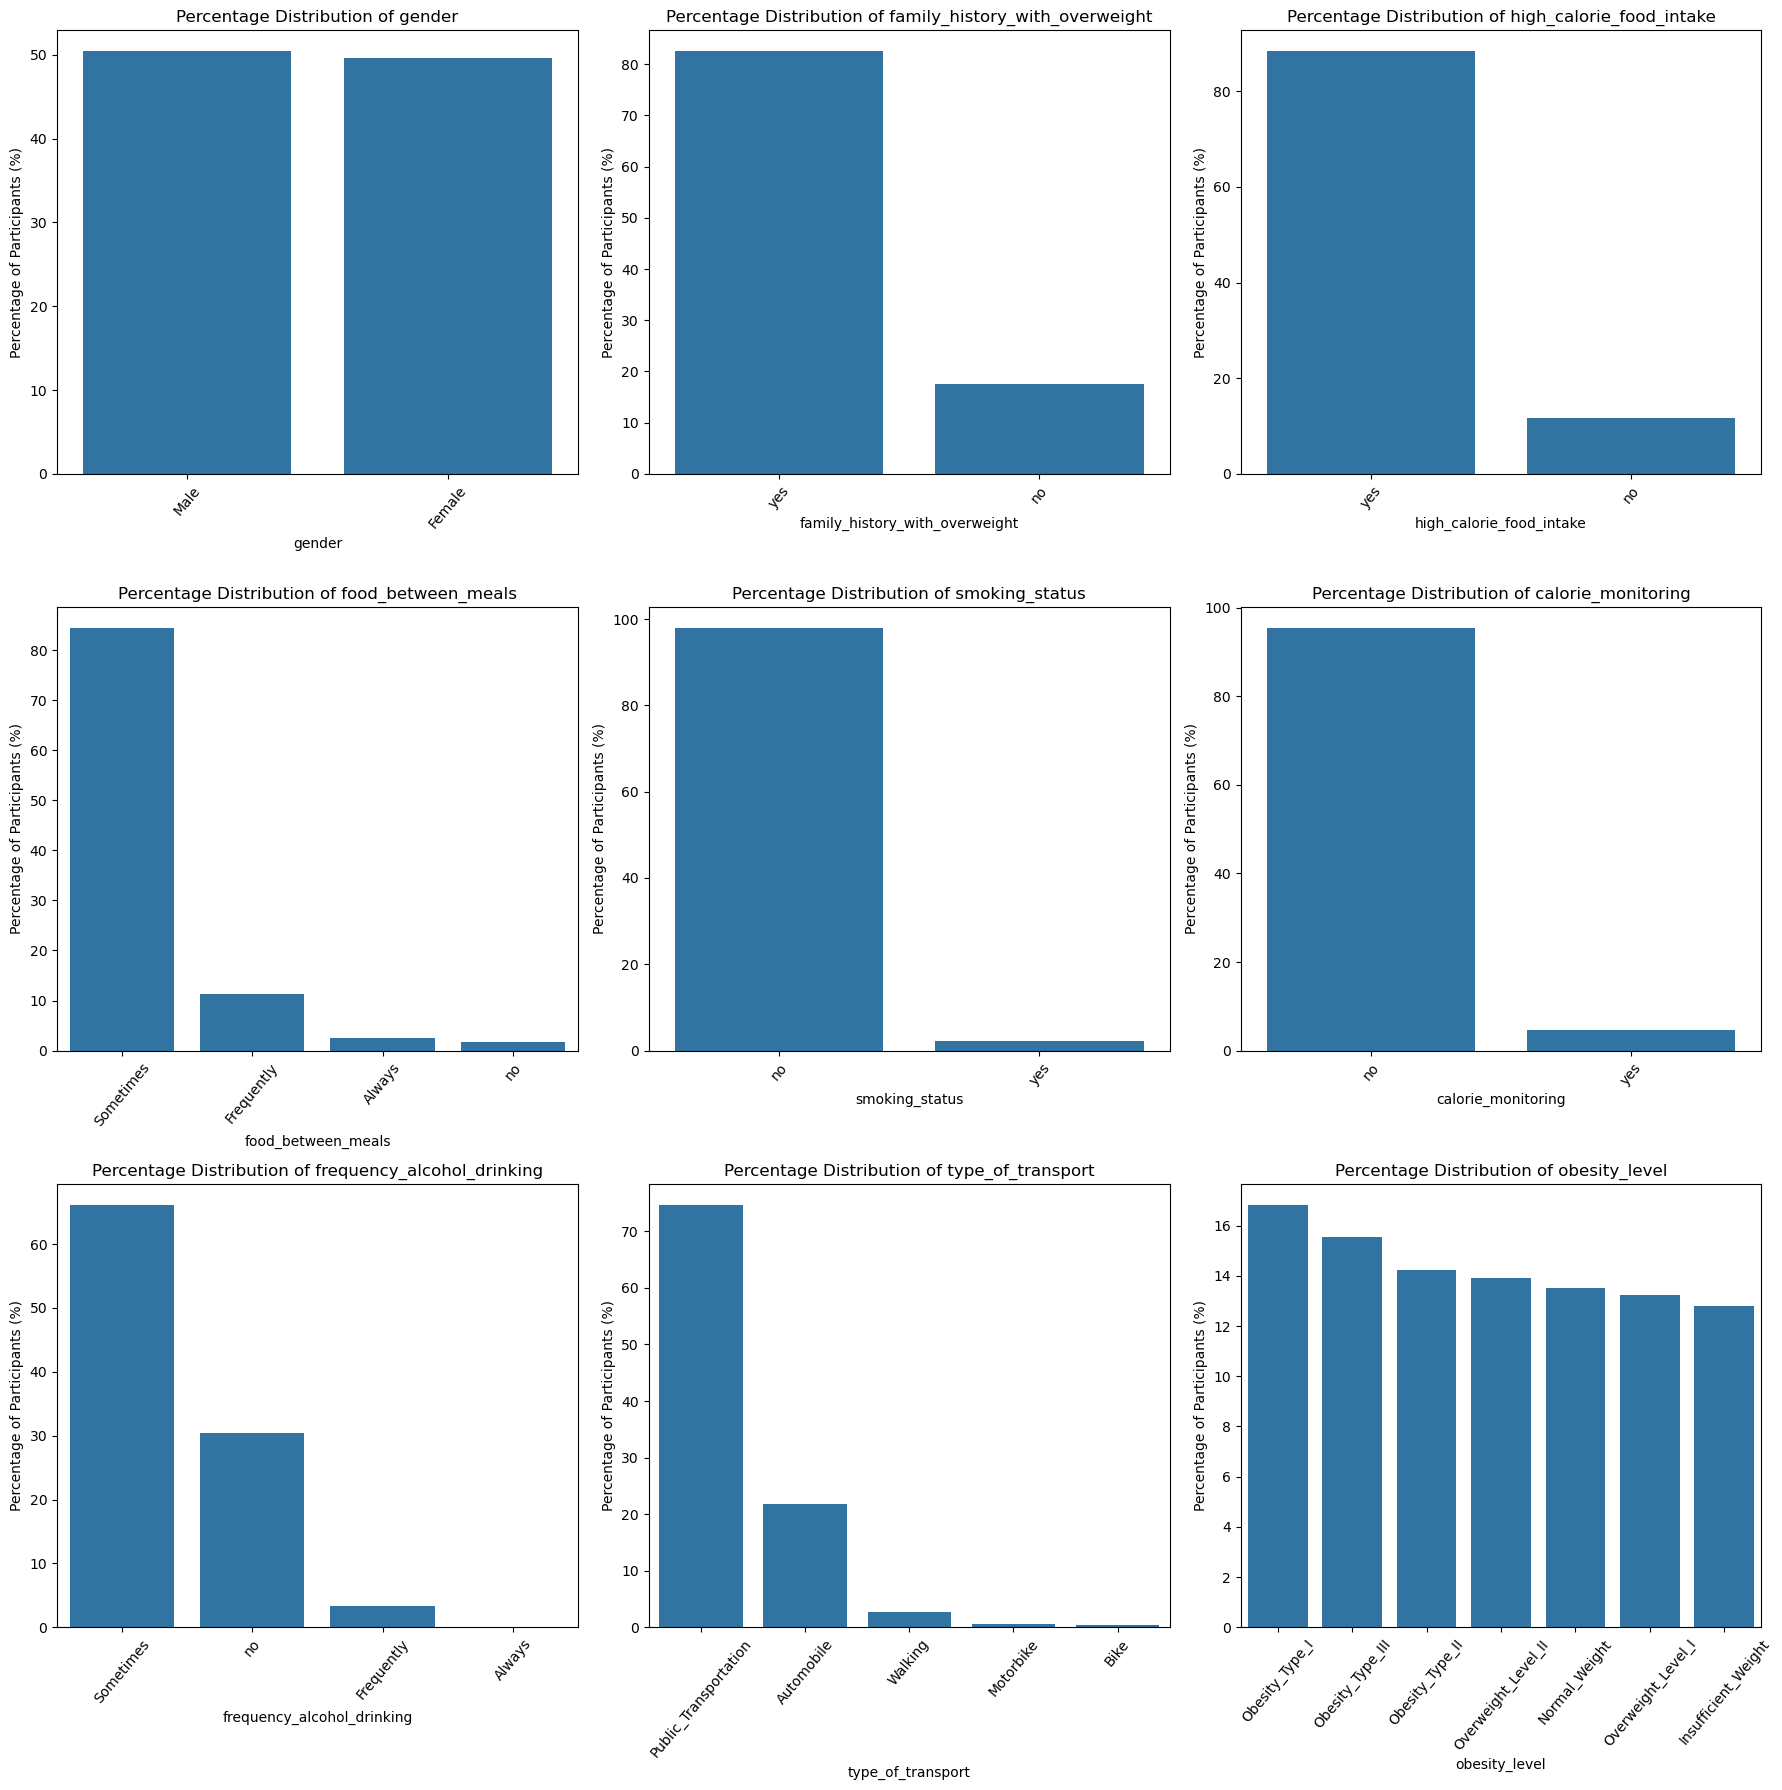

In [33]:
#Like geneder, we will check value counts for other categorical columns and plot them as barplots
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df1[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax) #.index gives the actual categories in each column and .values gives the values
    # Fix the tick positions
    # Use the number of items or specific locations (e.g., range(len(categories)))
    ax.set_xticks(range(len(category_counts)))

    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Participants (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity
    # Now set the custom labels (e.g., rotated for readability)
    ax.set_xticklabels(category_counts.index, rotation=50) # You can add your custom labels here

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

#### Above we can see there are different distributions of different categories.

high_calorie_food_intake         no   yes
family_history_with_overweight           
no                               97   268
yes                             146  1576


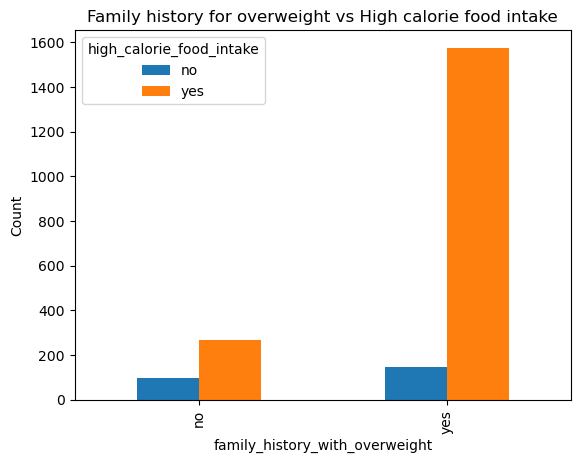

In [35]:
#Now we will see how 2 or more variables are linked together
crosstab = pd.crosstab(df1['family_history_with_overweight'], df1['high_calorie_food_intake'])
print(crosstab)

# Plotting the crosstab
crosstab.plot(kind='bar')
plt.title('Family history for overweight vs High calorie food intake')
plt.ylabel('Count')
plt.show()

frequency_alcohol_drinking      Always  Frequently  Sometimes   no
family_history_with_overweight                                    
no                                   0          16        246  103
yes                                  1          54       1134  533


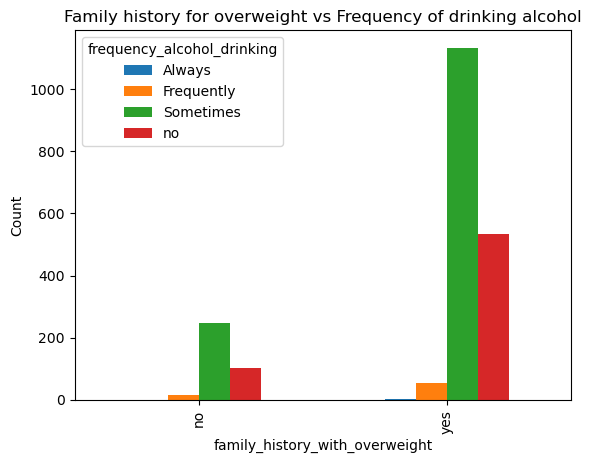

In [36]:
crosstab1 = pd.crosstab(df1['family_history_with_overweight'], df1['frequency_alcohol_drinking'])
print(crosstab1)

# Plotting the crosstab
crosstab1.plot(kind='bar')
plt.title('Family history for overweight vs Frequency of drinking alcohol')
plt.ylabel('Count')
plt.show()

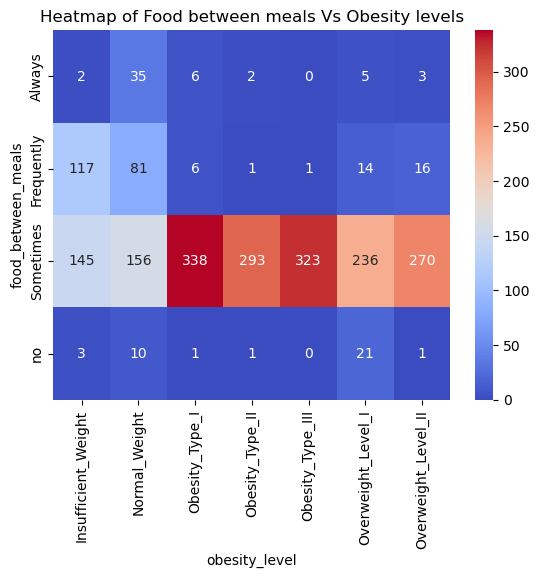

In [37]:
#Now we will see how food between meals is linked to obesity levels
crosstab2 = pd.crosstab(df1['food_between_meals'], df1['obesity_level'])
sns.heatmap(crosstab2, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Food between meals Vs Obesity levels')
plt.show()

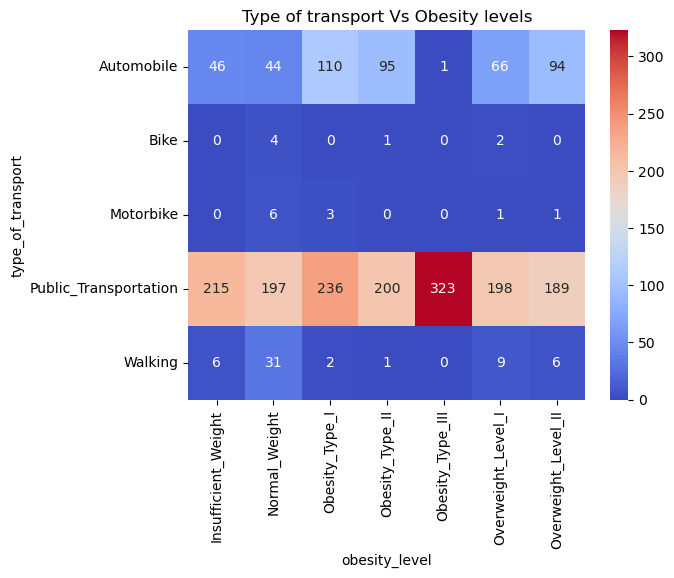

In [38]:
crosstab3 = pd.crosstab(df1['type_of_transport'], df1['obesity_level'])
sns.heatmap(crosstab3, annot=True, cmap='coolwarm',fmt="d")
plt.title('Type of transport Vs Obesity levels')
plt.show()

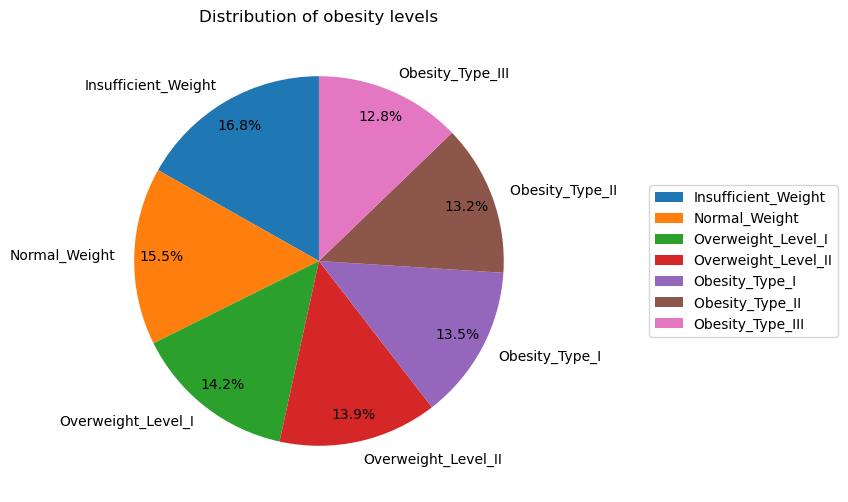

In [39]:
#We will check the distribution of the target variable before applying any algorithm
plt.figure(figsize=(6, 6))
#myexplode = [ 0, 0.2, 0, 0, 0, 0, 0]
plt.pie(df1['obesity_level'].value_counts(), labels=['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II ', 'Obesity_Type_III'], 
        autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.legend(loc='center left', bbox_to_anchor=(1.2, 0.5))
plt.title("Distribution of obesity levels")
plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1[df1.select_dtypes(include=['int','float']).columns] = scaler.fit_transform(df1[df1.select_dtypes(include=['int','float']).columns])  # Selecting only numerical features
df1.head()


#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()

#df1[df1.select_dtypes(include=['int','float']).columns] = scaler.fit_transform(df1[df1.select_dtypes(include=['int','float']).columns])  # Selecting only numerical features
#df1.head()

C:\Users\amrut\AppData\Local\Temp\ipykernel_3468\3772215870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[df1.select_dtypes(include=['int','float']).columns] = scaler.fit_transform(df1[df1.select_dtypes(include=['int','float']).columns])  # Selecting only numerical features


,gender,age,height_in_meters,weight_in_kgs,family_history_with_overweight,high_calorie_food_intake,vegetables_in_meal,number_of_daily_meals,food_between_meals,smoking_status,amount_of_water_daily_in_liters,calorie_monitoring,frequency_physical_activity_days_per_week,use_of_tech_device_time_in_hours,frequency_alcohol_drinking,type_of_transport,obesity_level
0,Female,-0.473866,-0.887864,-0.873605,yes,no,-0.788364,0.183899,Sometimes,no,-0.007810,no,-1.186977,0.554211,no,Public_Transportation,Normal_Weight
1,Female,-0.473866,-1.963531,-1.179922,yes,no,1.082164,0.183899,Sometimes,yes,1.636552,yes,2.328908,-1.090505,Sometimes,Public_Transportation,Normal_Weight
2,Male,0.007852,1.048338,-0.375838,yes,no,-0.788364,0.183899,Sometimes,no,-0.007810,no,1.156947,0.554211,Frequently,Public_Transportation,Normal_Weight
3,Male,0.971287,1.048338,0.007059,no,no,1.082164,0.183899,Sometimes,no,-0.007810,no,1.156947,-1.090505,Frequently,Walking,Overweight_Level_I
4,Male,-0.233007,0.833204,0.114270,no,no,-0.788364,0.183899,Sometimes,no,-0.007810,no,-1.186977,-1.090505,Sometimes,Public_Transportation,Overweight_Level_II


### <h1 style="color: blue;">Feature Engineering</h1>

In [42]:
nominal_cols = ['gender', 'family_history_with_overweight', 'high_calorie_food_intake', 'food_between_meals', 
                   'smoking_status', 'calorie_monitoring', 'frequency_alcohol_drinking', 'type_of_transport']

#We are going to drop the target variable 'obesity_level'. This variable will be used when we use machine learning classification.
#So basically, we are not going to include that variable in the nominal cols.
df2 = pd.get_dummies(df1, columns=nominal_cols, drop_first=True, dtype=int)
df2.head(3)

,age,height_in_meters,weight_in_kgs,vegetables_in_meal,number_of_daily_meals,amount_of_water_daily_in_liters,frequency_physical_activity_days_per_week,use_of_tech_device_time_in_hours,obesity_level,gender_Male,...,food_between_meals_no,smoking_status_yes,calorie_monitoring_yes,frequency_alcohol_drinking_Frequently,frequency_alcohol_drinking_Sometimes,frequency_alcohol_drinking_no,type_of_transport_Bike,type_of_transport_Motorbike,type_of_transport_Public_Transportation,type_of_transport_Walking
0,-0.473866,-0.887864,-0.873605,-0.788364,0.183899,-0.007810,-1.186977,0.554211,Normal_Weight,0,...,0,0,0,0,0,1,0,0,1,0
1,-0.473866,-1.963531,-1.179922,1.082164,0.183899,1.636552,2.328908,-1.090505,Normal_Weight,0,...,0,1,1,0,1,0,0,0,1,0
2,0.007852,1.048338,-0.375838,-0.788364,0.183899,-0.007810,1.156947,0.554211,Normal_Weight,1,...,0,0,0,1,0,0,0,0,1,0


In [43]:
df2.columns

Index(['age', 'height_in_meters', 'weight_in_kgs', 'vegetables_in_meal',
       'number_of_daily_meals', 'amount_of_water_daily_in_liters',
       'frequency_physical_activity_days_per_week',
       'use_of_tech_device_time_in_hours', 'obesity_level', 'gender_Male',
       'family_history_with_overweight_yes', 'high_calorie_food_intake_yes',
       'food_between_meals_Frequently', 'food_between_meals_Sometimes',
       'food_between_meals_no', 'smoking_status_yes', 'calorie_monitoring_yes',
       'frequency_alcohol_drinking_Frequently',
       'frequency_alcohol_drinking_Sometimes', 'frequency_alcohol_drinking_no',
       'type_of_transport_Bike', 'type_of_transport_Motorbike',
       'type_of_transport_Public_Transportation', 'type_of_transport_Walking'],
      dtype='object')

In [44]:
#We will drop the column obesity_level because it is a target variable for this classification model.
df3 = df2.drop(['obesity_level'], axis=1)
df3.columns

Index(['age', 'height_in_meters', 'weight_in_kgs', 'vegetables_in_meal',
       'number_of_daily_meals', 'amount_of_water_daily_in_liters',
       'frequency_physical_activity_days_per_week',
       'use_of_tech_device_time_in_hours', 'gender_Male',
       'family_history_with_overweight_yes', 'high_calorie_food_intake_yes',
       'food_between_meals_Frequently', 'food_between_meals_Sometimes',
       'food_between_meals_no', 'smoking_status_yes', 'calorie_monitoring_yes',
       'frequency_alcohol_drinking_Frequently',
       'frequency_alcohol_drinking_Sometimes', 'frequency_alcohol_drinking_no',
       'type_of_transport_Bike', 'type_of_transport_Motorbike',
       'type_of_transport_Public_Transportation', 'type_of_transport_Walking'],
      dtype='object')

In [45]:
df3.shape

(2087, 23)

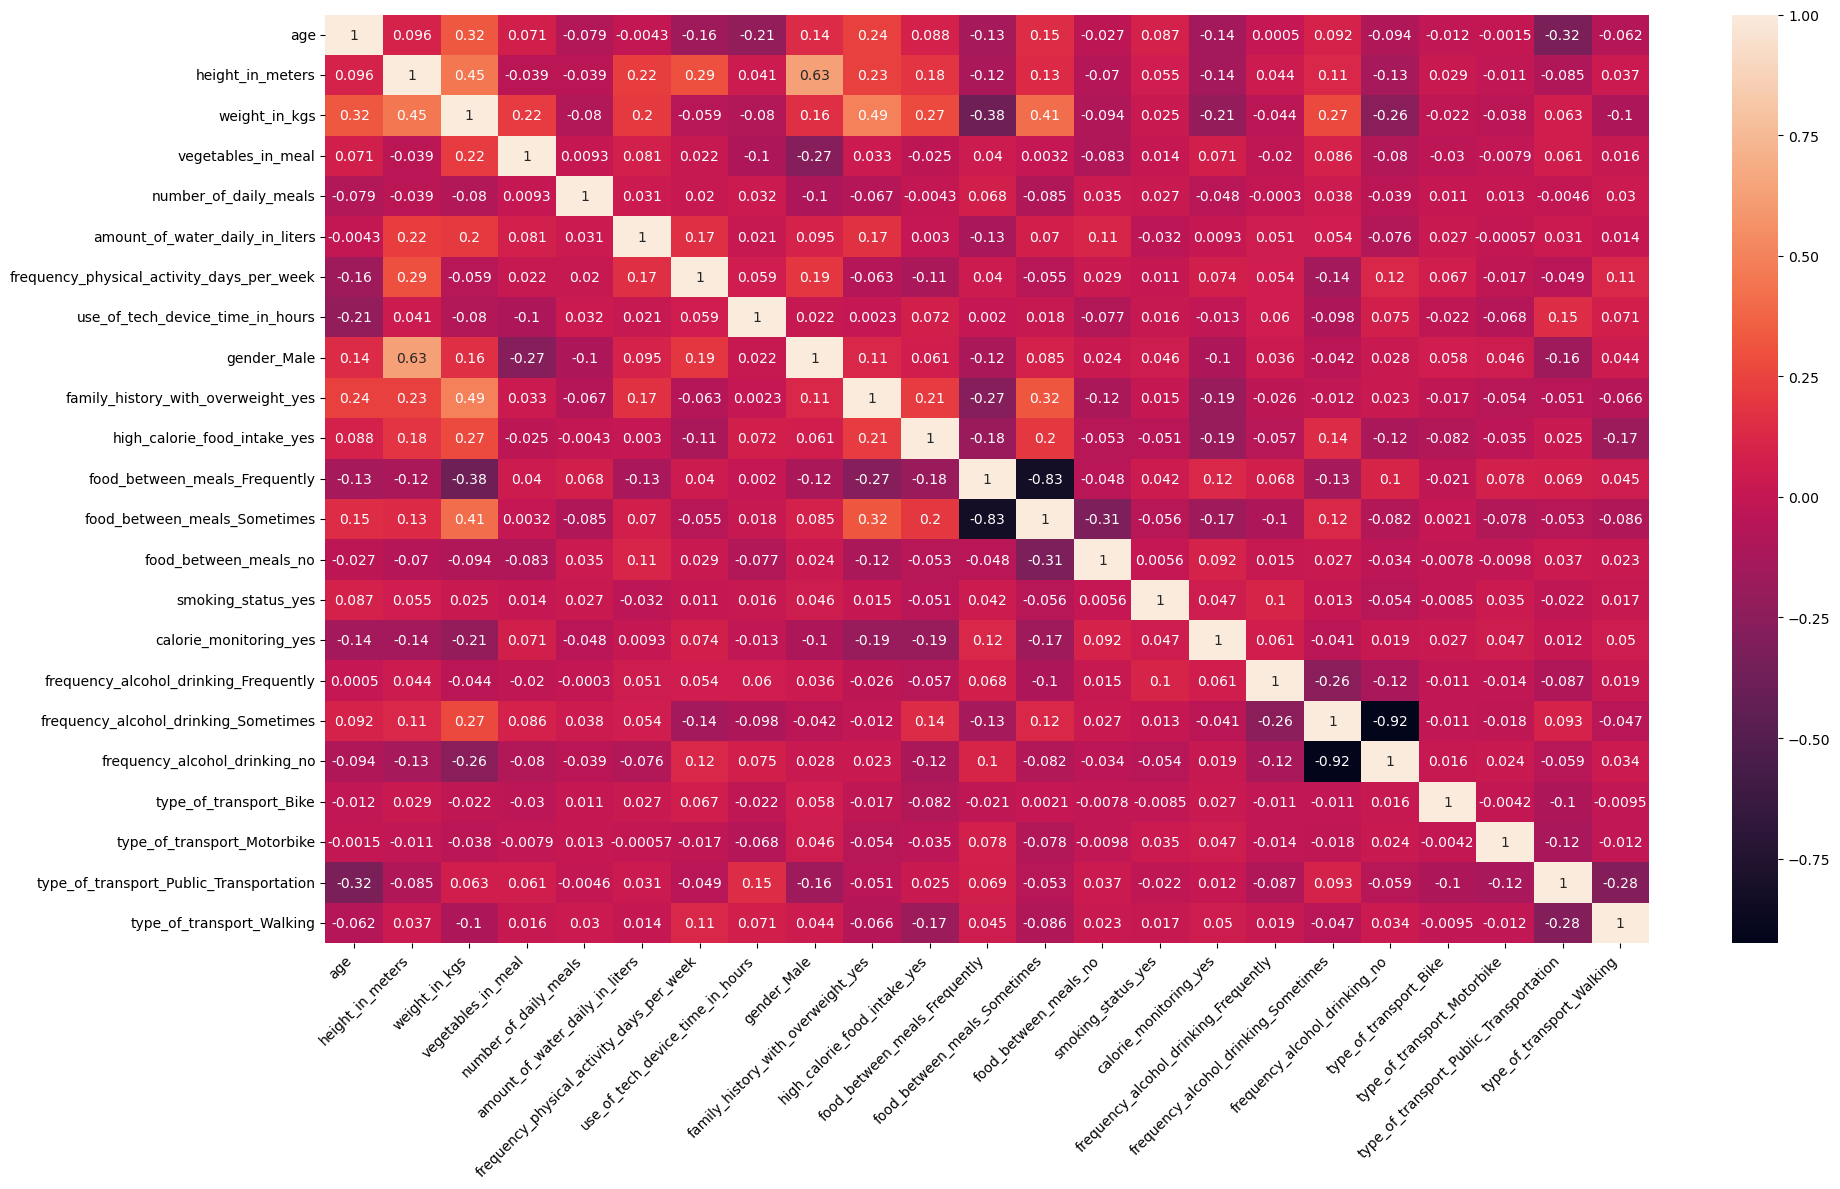

In [46]:
#Calculate VIF for multicollinearity
cm = df3.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
X = df3
y = df2['obesity_level']

In [48]:
# Performing feature selection using Decision Tree
FS_dt = DecisionTreeClassifier(max_depth=10).fit(X, y)

In [49]:
# Creating a dataframe of feature_importances_
feature_select = pd.DataFrame()
feature_select['Features'] = X.columns
feature_select['feature_importances_'] = FS_dt.feature_importances_
feature_select.sort_values(by='feature_importances_', ascending=False)

,Features,feature_importances_
2,weight_in_kgs,0.465507
1,height_in_meters,0.219040
8,gender_Male,0.164226
0,age,0.046588
18,frequency_alcohol_drinking_no,0.023284
10,high_calorie_food_intake_yes,0.020560
3,vegetables_in_meal,0.018896
7,use_of_tech_device_time_in_hours,0.007690
5,amount_of_water_daily_in_liters,0.007569
11,food_between_meals_Frequently,0.005900


In [50]:
#Only keep the important columns
X_reduced = X.filter(items=["weight_in_kgs", "height_in_meters", "gender_Male", "age", "frequency_alcohol_drinking_no",
                                    "high_calorie_food_intake_yes",  "vegetables_in_meal", "amount_of_water_daily_in_liters",
                                     "food_between_meals_Frequently", "use_of_tech_device_time_in_hours",  "food_between_meals_Sometimes",
                                    "smoking_status_yes", "number_of_daily_meals", "frequency_physical_activity_days_per_week",
                                    "family_history_with_overweight_yes", "type_of_transport_Walking", 
                               "frequency_alcohol_drinking_Sometimes"
    ]) 

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.3, random_state = 10)

# Check shape of the X_train, X_test, y_train, y_test features to get an idea of how rows are distributed
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (1460, 17)
x test:  (627, 17)
y train:  (1460,)
y test:  (627,)


In [52]:
# Define the custom mapping
rating_map = {'Insufficient_Weight' : 0, 'Normal_Weight' : 1, 'Overweight_Level_I' : 2, 'Overweight_Level_II' : 3,
 'Obesity_Type_I' : 4, 'Obesity_Type_II' : 5, 'Obesity_Type_III' : 6}

# Apply the mapping
y1 = y.replace(rating_map)


C:\Users\amrut\AppData\Local\Temp\ipykernel_3468\4223836420.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y1 = y.replace(rating_map)


In [69]:
#!pip install mord
import mord
from sklearn.metrics import accuracy_score


# Initialize model
model = mord.LogisticAT()

model.fit(X_reduced, y1)

y_pred_ord = model.predict(X_reduced)

accuracy = accuracy_score(y1, y_pred_ord)
accuracy
print("Accuracy:", accuracy_score(y1, y_pred_ord))

Accuracy: 0.9012937230474365


In [71]:
# Initialize and train a Logistic Regression model using the training data
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

LogisticRegression()

In [72]:
# Step 1: Make predictions on the test set using the trained model
logistic_y_pred = logistic_model.predict(X_test)

# Step 2: Evaluate the model using a classification report, including precision, recall, and accuracy metrics
report = classification_report(y_test, logistic_y_pred)
print("Classification Report:")
print(report)

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94        83
      Normal_Weight       0.88      0.74      0.81        90
     Obesity_Type_I       0.92      0.93      0.92        86
    Obesity_Type_II       0.98      1.00      0.99        91
   Obesity_Type_III       1.00      0.99      0.99        98
 Overweight_Level_I       0.78      0.84      0.81        95
Overweight_Level_II       0.82      0.80      0.81        84

           accuracy                           0.90       627
          macro avg       0.90      0.90      0.90       627
       weighted avg       0.90      0.90      0.90       627



In [75]:
# Creating DT model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=4)

In [76]:
# Training the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [77]:
# Determining score of test and train dataset
print('Training score is: %0.2f' % dt_model.score(X_train, y_train)) 
print('Testing score is: %0.2f' % dt_model.score(X_test, y_test)) 

Training score is: 0.78
Testing score is: 0.78


In [89]:
#SVM modelling
from sklearn.svm import SVC
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

# Step 4: Print accuracy score
print("Linear Kernel SVM Accuracy on Test Data:", model_linear.score(X_test, y_test))

Linear Kernel SVM Accuracy on Test Data: 0.9649122807017544


In [ ]:
# Step 5: Evaluate the model
y_pred_linear = model_linear.predict(X_test)
print("Classification Report for Linear Kernel SVM:")
print(classification_report(y_test, y_pred_linear))

print('*' * 50)

print("Confusion Matrix for Linear Kernel SVM:")
print(confusion_matrix(y_test, y_pred_linear))

In [79]:
#Use XGBoost algorithm
!pip install xgboost
from xgboost import XGBClassifier

In [83]:
X_train_xg, X_test_xg, y_train_xg, y_test_xg = train_test_split(X_reduced, y1, test_size = 0.3, random_state = 10)

# Check shape of the X_train, X_test, y_train, y_test features to get an idea of how rows are distributed
print("x train: ",X_train_xg.shape)
print("x test: ",X_test_xg.shape)
print("y train: ",y_train_xg.shape)
print("y test: ",y_test_xg.shape)

x train:  (1460, 17)
x test:  (627, 17)
y train:  (1460,)
y test:  (627,)


In [92]:
model_xg = XGBClassifier(
    objective='multi:softmax',
    n_estimators=100,
    use_label_encoder=False, # Set to False to avoid a deprecation warning
    eval_metric='mlogloss'   # A common metric for multiclass problems
)

# Fit the model
model_xg.fit(X_train_xg, y_train_xg)

C:\Users\amrut\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:36:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [94]:
# Make predictions on the test set
y_pred_xg = model_xg.predict(X_test_xg)

# Evaluate the model
accuracy = accuracy_score(y_test_xg, y_pred_xg)
print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 97.13%


### Error Analysis

In [97]:
residuals = y_pred_xg - y_test_xg #This gives the difference between actual values and predicted values.
residuals_pct = (residuals / y_test_xg) * 100 #This is the difference in terms of percentage.

#We will create a dataframe to see the values up close
results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
155,Normal_Weight,1,0,0.0
204,Normal_Weight,1,0,0.0
1281,Obesity_Type_I,4,0,0.0
1642,Obesity_Type_II,5,0,0.0
1347,Obesity_Type_I,4,0,0.0


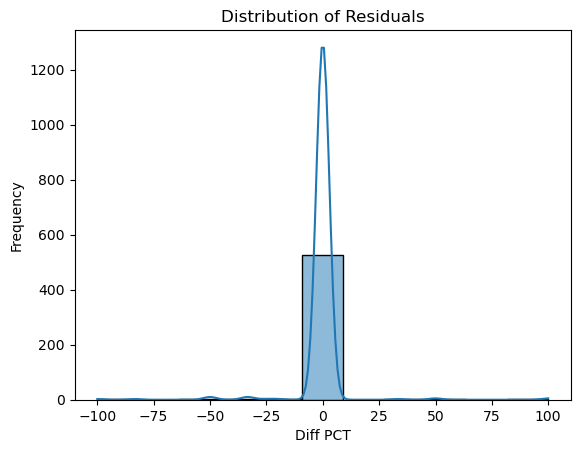

In [99]:
#We will check the distribution of these errors by plotting it. It will be the percentage error distribution.
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [101]:
X_test_xg.shape

(627, 17)

In [103]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
94,Normal_Weight,0,-1,-100.000000
147,Obesity_Type_I,3,-1,-25.000000
1043,Overweight_Level_II,2,-1,-33.333333
987,Overweight_Level_II,2,-1,-33.333333
322,Insufficient_Weight,1,1,inf


In [105]:
extreme_results_df.shape

(18, 4)

In [107]:
#Now we need to see how much percent of predictions are extreme errors
extreme_errors_pct = extreme_results_df.shape[0]*100/results_df.shape[0]
extreme_errors_pct

2.8708133971291865